In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

We will do a simple example of a coin toss, and estimate the probability p. To simulate the coin toss, we will take 2 inputs, probability and time, and create a bernoulli random variable B  ( via np.random.binomial)

In [11]:
N= int(input("Input the number of trials "));
if N<=0:
    exit();
else:
    p = float(input("Enter the probability of the simulated coin"));
    if p<0 or p>1:
        print("Probability has to be between 0 and 1");
        exit();
    x = np.random.binomial(n=1, p=p, size=N)  # each value is 0 or 1, and x is a list of size N
    print("The estimated probability is : ", x.mean());


Input the number of trials  1000
Enter the probability of the simulated coin .22


The estimated probability is :  0.21


Next we move on to estimating $\pi$. This is done by computing the expectation of the number of points lying in the positive quadrant with distance less than or equal to 1 from the center. This is pi/4. For simplicity, we set the size as default

In [22]:
N=10000;
X = np.random.uniform(0,1,size=N)
Y=np.random.uniform(0,1,size=N);
Z = [np.sqrt(x**2 + y**2) for (x,y) in zip(X,Y)];
U = [1 for z in Z if z<=1]; # U is the indicator function for the point to be in the circle. 
print(4*sum(U)/N)

3.1588


We will now simulate GBM, via exact and finite difference method. 

In [14]:
# Parameters
S0 = 100       # Initial stock price
mu = 0.05      # Drift 
sigma = 0.2    # Volatility
T = 1.0        # Time horizon 
N = 365        # Number of time steps (daily)
M = 100        # Number of simulated paths

# Time increment
dt = T / N

# Initialize array to store paths
S = np.zeros((M, N + 1))
S_em = np.zeros((M, N+1))
S[:, 0] = S0
S_em[:,0]=S0

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\abhis\AppData\Local\Temp\ipykernel_9132\2636745117.py:2: SyntaxWarning: invalid escape sequence '\m'
  Recall GBM = dS/S = \mu dt + \simga dB. The solution is S_t = S_0 * e^[(\mu - \sigma^2/2)t + \sigma W_t]


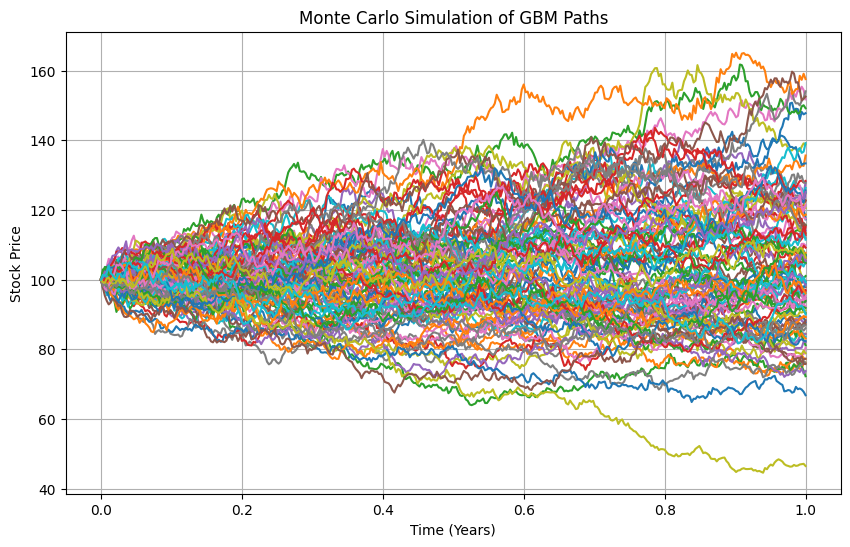

Expected terminal stock price: 104.58


In [15]:
""" Simulate GBM paths
Recall GBM = dS/S = \mu dt + \simga dB. The solution is S_t = S_0 * e^[(\mu - \sigma^2/2)t + \sigma W_t]
When we are dividing into discrete time interval, using the properties of Brownian motion we can write 
S_{t+dt}/S_{t} = e^[(\mu - \sigma^2/2) dt + \sigma N(0,dt)] = e^[(\mu - \sigma^2/2) dt + \sigma \sqrt(dt) N(0,1)] """
for i in range(1, N + 1):
    Z = np.random.standard_normal(M)  # Generate a list of M numbers from standard normal distribution. 
    S[:, i] = S[:, i-1]*np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z) # We are doing this from the exact solution.
# Plot simulated paths
plt.figure(figsize=(10,6))
for j in range(M):
    plt.plot(np.linspace(0, T, N+1), S[j], lw=1.5)
plt.title("Monte Carlo Simulation of GBM Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()

expected_ST = np.mean(S[:, -1])
print(f"Expected terminal stock price: {expected_ST:.2f}")

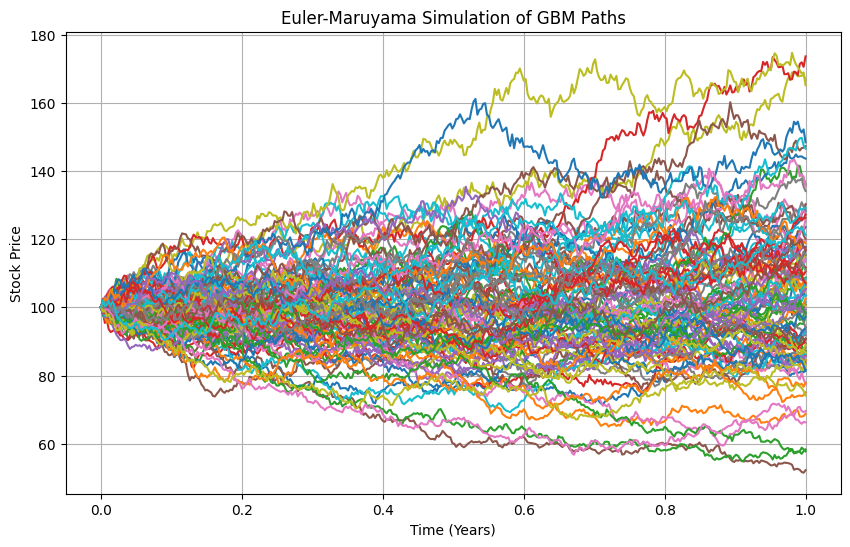

Expected terminal stock price: 104.47


In [16]:
# Simulate GBM using Euler's Differential Equation dS/S = mu dt + \sigma dW_t, and just expand dS, and dW_t in terms of forward difference operator 
for i in range(1, N + 1):
    Z = np.random.standard_normal(M)  # standard normal random numbers
    S_em[:, i] = S_em[:, i-1] + mu * S_em[:, i-1] * dt + sigma * S_em[:, i-1] * np.sqrt(dt) * Z # Euler's Method

# Plot simulated paths
plt.figure(figsize=(10,6))
for j in range(M):
    plt.plot(np.linspace(0, T, N+1), S_em[j], lw=1.5)
plt.title("Euler-Maruyama Simulation of GBM Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()

# Example: compute expected terminal price
expected_ST_em = np.mean(S_em[:, -1])
print(f"Expected terminal stock price: {expected_ST_em:.2f}")